# Diabetes Health Indicators — EDA & Preprocessing

Dataset: CDC BRFSS 2015 with Race variable added  
251,467 rows · 22 features · 1 target (`Diabetes_binary`)

This notebook does basic EDA and preprocessing per the proposal:
- Standardize continuous features
- Keep ordinal and binary features as-is
- Split into train/val/test (70/15/15)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

DATA_PATH = 'data/diabetes_binary_health_indicators_BRFSS2015_with_race.csv'

## 1. Load Data

In [ ]:
df = pd.read_csv(DATA_PATH)
print(f'Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
df.head()

Shape: (251467, 23)
Columns: ['Diabetes_binary', 'HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income', 'Race']


,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income,Race
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0,1.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0,1.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0,1.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0,7.0


In [ ]:
# Check for missing values
print('Missing values:', df.isnull().sum().sum())

Missing values: 0


## 2. Class Distribution

Important to understand the class imbalance before modeling.

In [ ]:
counts = df['Diabetes_binary'].value_counts().sort_index()
print('Class counts:')
print(f'  0 (No Diabetes):           {counts[0]:,}')
print(f'  1 (Prediabetes/Diabetes):  {counts[1]:,}')
print(f'\nPositive rate: {counts[1] / len(df):.1%}')
print(f'Imbalance ratio: {counts[0]/counts[1]:.1f}:1')

Class counts:
  0 (No Diabetes):           211,900
  1 (Prediabetes/Diabetes):  39,567

Positive rate: 15.7%
Imbalance ratio: 5.4:1


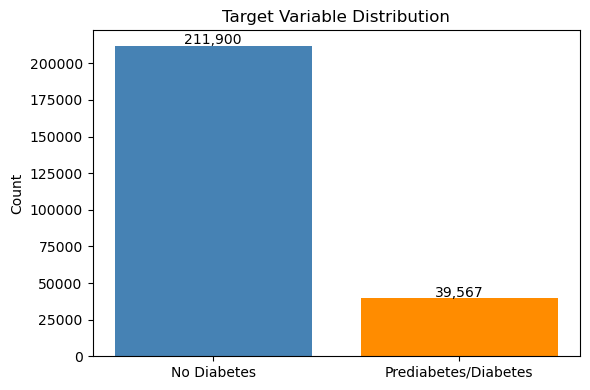

In [ ]:
# Simple bar chart
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(['No Diabetes', 'Prediabetes/Diabetes'], counts.values, color=['steelblue', 'darkorange'])
ax.set_ylabel('Count')
ax.set_title('Target Variable Distribution')
for i, v in enumerate(counts.values):
    ax.text(i, v + 1000, f'{v:,}', ha='center')
plt.tight_layout()
plt.savefig('data/fig_class_distribution.png')
plt.show()

## 3. Feature Summary

Quick look at feature statistics.

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Diabetes_binary,251467.0,0.157345,0.364126,0.0,0.0,0.0,0.0,1.0
HighBP,251467.0,0.428915,0.494922,0.0,0.0,0.0,1.0,1.0
HighChol,251467.0,0.424163,0.494216,0.0,0.0,0.0,1.0,1.0
CholCheck,251467.0,0.962842,0.189149,0.0,1.0,1.0,1.0,1.0
BMI,251467.0,28.380841,6.606212,12.0,24.0,27.0,31.0,98.0
Smoker,251467.0,0.442837,0.496723,0.0,0.0,0.0,1.0,1.0
Stroke,251467.0,0.040467,0.197051,0.0,0.0,0.0,0.0,1.0
HeartDiseaseorAttack,251467.0,0.094008,0.291841,0.0,0.0,0.0,0.0,1.0
PhysActivity,251467.0,0.756668,0.429095,0.0,1.0,1.0,1.0,1.0
Fruits,251467.0,0.634155,0.481667,0.0,0.0,1.0,1.0,1.0


## 4. Top Correlations with Target

Which features are most correlated with diabetes?

In [ ]:
correlations = df.corr()['Diabetes_binary'].drop('Diabetes_binary')
correlations = correlations.sort_values(key=abs, ascending=False)
print('Correlations with Diabetes_binary:')
print(correlations.to_string())

Correlations with Diabetes_binary:
GenHlth                 0.300835
HighBP                  0.270140
BMI                     0.223740
DiffWalk                0.222354
HighChol                0.210530
Age                     0.185608
HeartDiseaseorAttack    0.176943
PhysHlth                0.174895
Income                 -0.173015
Education              -0.131466
PhysActivity           -0.121508
Stroke                  0.104742
MentHlth                0.074662
CholCheck               0.067567
Smoker                  0.062381
Veggies                -0.059211
HvyAlcoholConsump      -0.056894
Race                    0.046752
Fruits                 -0.042209
NoDocbcCost             0.038525
Sex                     0.029598
AnyHealthcare           0.013992


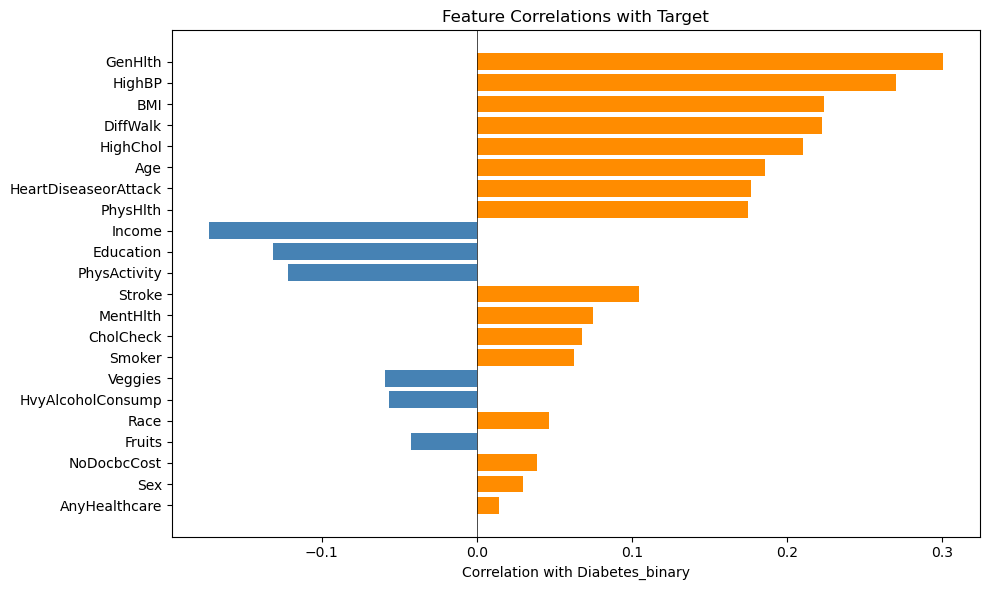

In [ ]:
# Bar chart of correlations
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['darkorange' if x > 0 else 'steelblue' for x in correlations.values]
ax.barh(correlations.index[::-1], correlations.values[::-1], color=colors[::-1])
ax.set_xlabel('Correlation with Diabetes_binary')
ax.set_title('Feature Correlations with Target')
ax.axvline(0, color='black', linewidth=0.5)
plt.tight_layout()
plt.savefig('data/fig_correlations.png')
plt.show()

## 5. Preprocessing

Per the proposal:
- Continuous features (BMI, MentHlth, PhysHlth): standardize with z-score
- Ordinal features (GenHlth, Age, Education, Income): keep as integers
- Binary features: unchanged
- Race: kept as integer 1-8 (nominal, but tree models handle this fine)

In [ ]:
# Define feature types
CONTINUOUS = ['BMI', 'MentHlth', 'PhysHlth']
TARGET = 'Diabetes_binary'

# Separate features and target
feature_cols = [c for c in df.columns if c != TARGET]
X = df[feature_cols].copy()
y = df[TARGET].copy()

print(f'Features: {len(feature_cols)}')
print(f'Continuous (to standardize): {CONTINUOUS}')

Features: 22
Continuous (to standardize): ['BMI', 'MentHlth', 'PhysHlth']


In [ ]:
# Standardize continuous features
scaler = StandardScaler()
X[CONTINUOUS] = scaler.fit_transform(X[CONTINUOUS])

print('After standardization:')
with pd.option_context('display.float_format', '{:.2f}'.format):
    print(X[CONTINUOUS].describe())

After standardization:
            BMI  MentHlth  PhysHlth
count 251467.00 251467.00 251467.00
mean      -0.00     -0.00      0.00
std        1.00      1.00      1.00
min       -2.48     -0.43     -0.49
25%       -0.66     -0.43     -0.49
50%       -0.21     -0.43     -0.49
75%        0.40     -0.16     -0.14
max       10.54      3.62      2.96


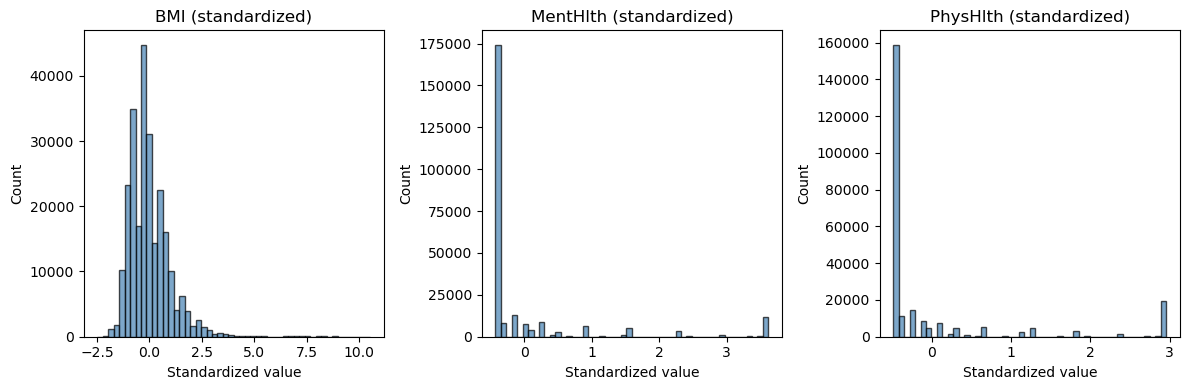

In [ ]:
# Visualize standardized continuous features
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for i, col in enumerate(CONTINUOUS):
    axes[i].hist(X[col], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
    axes[i].set_title(f'{col} (standardized)')
    axes[i].set_xlabel('Standardized value')
    axes[i].set_ylabel('Count')
plt.tight_layout()
plt.savefig('data/fig_standardized_features.png')
plt.show()

## 6. Train/Val/Test Split

70/15/15 stratified split to preserve class balance.

In [ ]:
SEED = 42

# First split: 70% train, 30% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=SEED, stratify=y
)

# Second split: 50/50 of temp -> 15% val, 15% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=SEED, stratify=y_temp
)

print(f'Train: {X_train.shape[0]:,} rows ({X_train.shape[0]/len(df):.0%})')
print(f'Val:   {X_val.shape[0]:,} rows ({X_val.shape[0]/len(df):.0%})')
print(f'Test:  {X_test.shape[0]:,} rows ({X_test.shape[0]/len(df):.0%})')
print(f'\nPositive rate preserved:')
print(f'  Train: {y_train.mean():.1%}')
print(f'  Val:   {y_val.mean():.1%}')
print(f'  Test:  {y_test.mean():.1%}')

Train: 176,026 rows (70%)
Val:   37,720 rows (15%)
Test:  37,721 rows (15%)

Positive rate preserved:
  Train: 15.7%
  Val:   15.7%
  Test:  15.7%


## 7. Save Processed Data

In [ ]:
import os
os.makedirs('data/processed', exist_ok=True)

# Combine X and y for each split
train_df = X_train.copy()
train_df[TARGET] = y_train.values

val_df = X_val.copy()
val_df[TARGET] = y_val.values

test_df = X_test.copy()
test_df[TARGET] = y_test.values

# Save
train_df.to_csv('data/processed/train.csv', index=False)
val_df.to_csv('data/processed/val.csv', index=False)
test_df.to_csv('data/processed/test.csv', index=False)

print('Saved:')
print('  data/processed/train.csv')
print('  data/processed/val.csv')
print('  data/processed/test.csv')

Saved:
  data/processed/train.csv
  data/processed/val.csv
  data/processed/test.csv
